In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import dexplore as dx 
import xarray as xr
import os
import sys
import glob
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

sys.path.append(os.path.abspath("steele-lab-analysis-functions"))
import analysis_functions.core as af

In [166]:
dx.refresh_bokeh()

Loading BokehJS ...

In [47]:
def params_resonators(result,
                      show = False):
    f0 = result.params['f0'].value # GHz
    kt = result.params['kt'].value # GHz
    re_shift = result.params['re_shift'].value
    im_shift = result.params['im_shift'].value
    re_a_in = result.params['re_a_in'].value
    im_a_in = result.params['im_a_in'].value
    
    x_center = re_shift + (re_a_in / 2)
    y_center = im_shift + (im_a_in / 2)
    radius = np.sqrt(re_a_in**2 + im_a_in**2) / 2
    
    kc = radius * kt
    ki = kt - kc
    
    params = {'f0': f0,
              'kt': kt,
              'Qt': f0 / kt,
              'kc': kc,
              'Qc': f0 / kc,
              'ki': ki,
              'Qi': f0 / ki}
    
    if show:
        print('')
        print(f'=== Resonator parameters ===')
        print(f'\n f0 = {f0:.6f} GHz')
        print('')
        print(f'kt = {kt*1e3:.3f} MHz')
        print(f'kc = {kc*1e3:.3f} MHz')
        print(f'ki = {ki*1e3:.3f} MHz')
        print('')
        print(f'Qt = {f0 / kt:.1f}')
        print(f'Qc = {f0 / kc:.1f}')
        print(f'Qi = {f0 / ki:.1f}') 
        print('')
        print(f'=== Circle parameters ===')
        print(f'Center: ({x_center:.3f};{y_center:.3f})')
        print(f'Radius: {radius:.3f}')
    
    return params
    

In [48]:
base_folder = '/home/jovyan/steelelab/measurement_data/4KDIY/Pacome/single_resonance'

Dropping dummy coordinate/dimension 0: "None"
New dimensions are: ['freq', 'length']
Removing edelay: -7.599780945224 * (2*pi*freq) + 208.229254740348
Removing ['freq'] background with order 1 polynomial (mode: cpx)
f0: 4.39543050643898 +/- 1.0974315245724951e-05
kt: 0.005431649135267058 +/- 2.252533841795281e-05
re_a_in: -1.221731247405483 +/- 0.0034003913867698674
im_a_in: 0.12084909014666334 +/- 0.003645777919023598
T: -2.932258674495811 +/- 0.009145497529960682
re_shift: 0.9790666641387252 +/- 0.0005193374488358659
im_shift: -0.14950706326079002 +/- 0.000527300447404332


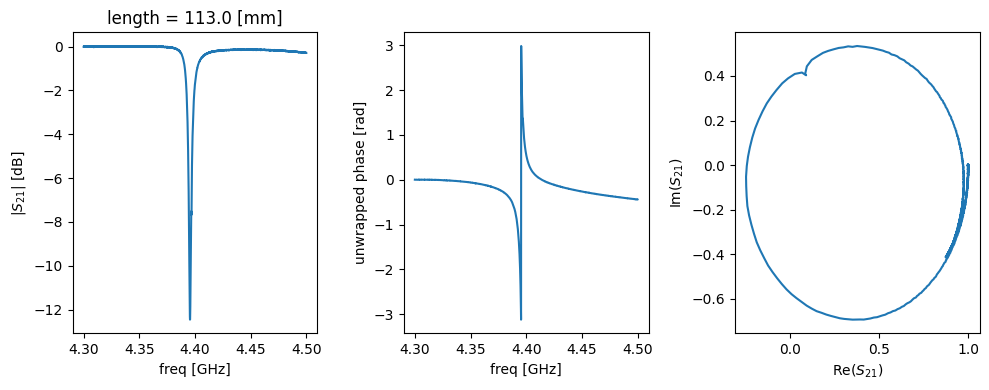

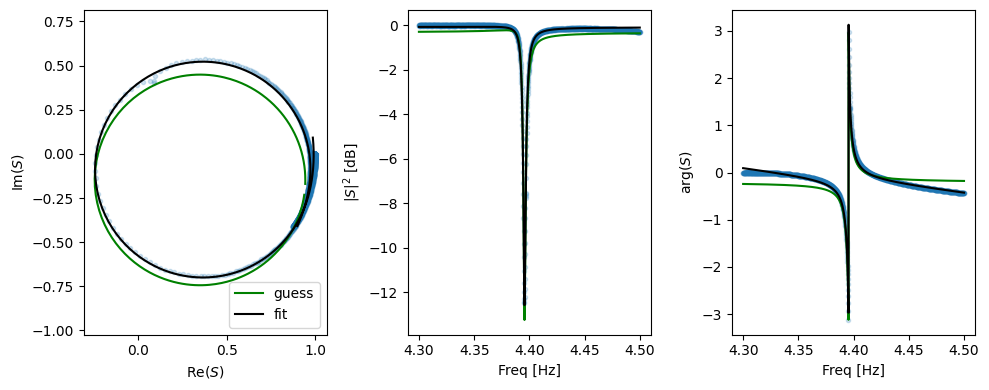

In [ ]:
file_folder = '2026-06-04_15.20.09_0001_VNA_freqsweep_FFx'
full_path = base_folder+'/'+file_folder
h5_files = sorted(glob.glob(full_path+'/*.h5'))

data = xr.open_dataset(h5_files[0])

translator = {'Frequency (Hz)':['freq', 'GHz', 1e9],
              'Cavity length (mm)':['length', 'mm', 1]}

data = af.format_data_xarray(
    data=data, 
    tool='VNA',   # a VNA was used to measure this dataset
    translator=translator,
    remove_edelay=[0,100,0,0])

data = af.bgd_remover_one_cut(data, window=[0,100,0,0], order=1, is_plot=False)

fig, ax = plt.subplots(1,3,figsize=(10,4))

data.mag.plot(ax=ax[0])
ax[1].plot(data.freq.values, np.unwrap(data.isel().arg.values))
ax[1].set_ylabel('unwrapped phase [rad]')
ax[1].set_xlabel('freq [GHz]')
ax[2].plot(data.cpx.values.real, data.cpx.values.imag)
ax[2].set_ylabel('Im($S_{21}$)')
ax[2].set_xlabel('Re($S_{21}$)')
fig.tight_layout()

_data = data.isel(length=0)
model = af.ComplexCircle()

# If no `guess` is specified, the fit function automatically calls the internal guess method
result = af.fit_single(model, _data.freq.values, _data.cpx.values, guess=None)

fig, ax = plt.subplots(1,3,figsize=(10,4))
# plot data
ax[0].plot(_data.cpx.real, _data.cpx.imag, '.', alpha=0.2)
ax[1].plot(_data.freq.values, _data.mag.values, '.', alpha=0.2)
ax[2].plot(_data.freq.values, _data.arg.values, '.', alpha=0.2)

# plot guess
guess = model.guess(_data.freq.values, _data.cpx.values)
_data_guess = model.function(_data.freq.values, **guess)
ax[0].plot(_data_guess.real, _data_guess.imag, 'g-', label='guess')
ax[1].plot(_data.freq.values, 20*np.log10(np.abs(_data_guess)), 'g-')
ax[2].plot(_data.freq.values, np.angle(_data_guess), 'g-')

# plot result
_data_fit = model.function(_data.freq.values, **result.params)
ax[0].plot(_data_fit.real, _data_fit.imag, 'k-', label='fit')
ax[1].plot(_data.freq.values, 20*np.log10(np.abs(_data_fit)), 'k-')
ax[2].plot(_data.freq.values, np.angle(_data_fit), 'k-')

ax[0].axis('equal')
ax[0].legend()
ax[0].set_xlabel('Re$(S)$')
ax[0].set_ylabel('Im$(S)$')
ax[1].set_xlabel('Freq [Hz]')
ax[1].set_ylabel(r'$|S|^2$ [dB]')
ax[2].set_xlabel('Freq [Hz]')
ax[2].set_ylabel(r'arg$(S)$')
fig.tight_layout()

# quick access to fitted parameters
for name in result.params.keys():
    print(f"{name}: {result.params[name].value} +/- {result.params[name].stderr}")
    
result

Dropping dummy coordinate/dimension 0: "None"
New dimensions are: ['freq', 'length']
Removing edelay: -8.102612818167 * (2*pi*freq) + 302.476734849452
Removing ['freq'] background with order 1 polynomial (mode: cpx)
f0: 5.965334704291272 +/- 6.624143110737931e-07
kt: 0.0013769304940354221 +/- 1.341047808530614e-06
re_a_in: -0.9037926214335713 +/- 0.0006039111787795536
im_a_in: 0.07063032502481774 +/- 0.0006267946554746762
T: 1.1596296408434825 +/- 0.002228753559021361
re_shift: 1.001602467868288 +/- 6.428263668121279e-05
im_shift: 0.052166974244456744 +/- 6.52247855712463e-05


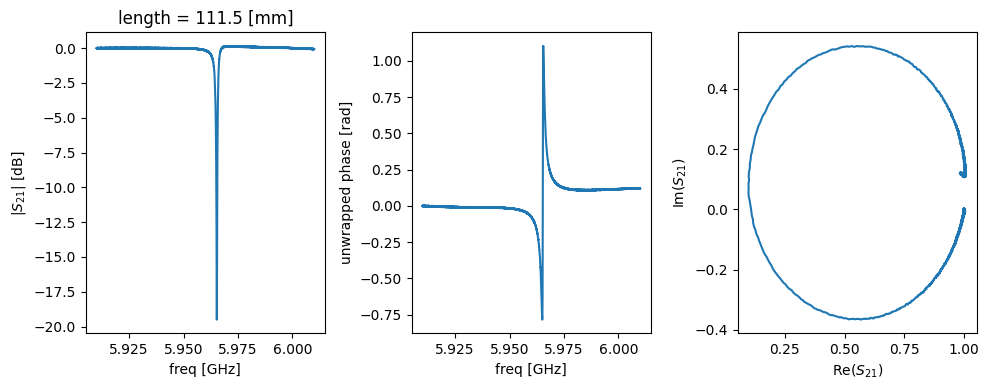

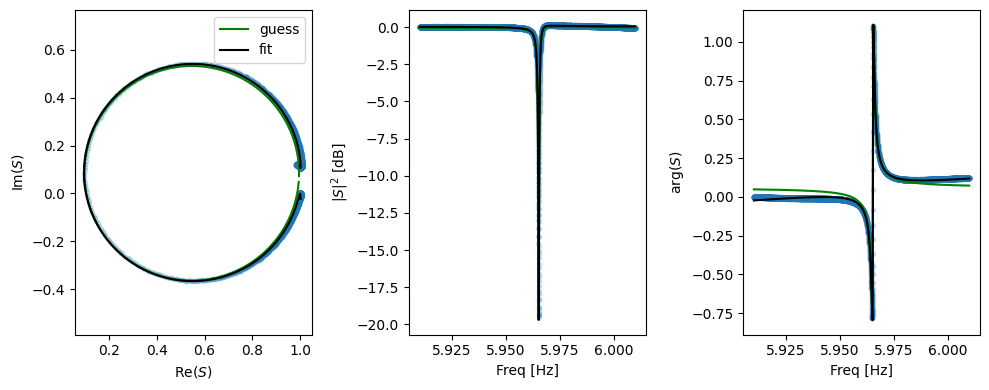

In [55]:
file_folder = '2026-06-04_16.13.11_0002_VNA_freqsweep_FFx'
full_path = base_folder+'/'+file_folder
h5_files = sorted(glob.glob(full_path+'/*.h5'))

data = xr.open_dataset(h5_files[0])

translator = {'Frequency (Hz)':['freq', 'GHz', 1e9],
              'Cavity length (mm)':['length', 'mm', 1]}

data = af.format_data_xarray(
    data=data, 
    tool='VNA',   # a VNA was used to measure this dataset
    translator=translator,
    remove_edelay=[0,100,0,0])

data = af.bgd_remover_one_cut(data, window=[0,100,0,0], order=1, is_plot=False)

fig, ax = plt.subplots(1,3,figsize=(10,4))

data.mag.plot(ax=ax[0])
ax[1].plot(data.freq.values, np.unwrap(data.isel().arg.values))
ax[1].set_ylabel('unwrapped phase [rad]')
ax[1].set_xlabel('freq [GHz]')
ax[2].plot(data.cpx.values.real, data.cpx.values.imag)
ax[2].set_ylabel('Im($S_{21}$)')
ax[2].set_xlabel('Re($S_{21}$)')
fig.tight_layout()

_data = data.isel(length=0)
model = af.ComplexCircle()

# If no `guess` is specified, the fit function automatically calls the internal guess method
result = af.fit_single(model, _data.freq.values, _data.cpx.values, guess=None)

fig, ax = plt.subplots(1,3,figsize=(10,4))
# plot data
ax[0].plot(_data.cpx.real, _data.cpx.imag, '.', alpha=0.2)
ax[1].plot(_data.freq.values, _data.mag.values, '.', alpha=0.2)
ax[2].plot(_data.freq.values, _data.arg.values, '.', alpha=0.2)

# plot guess
guess = model.guess(_data.freq.values, _data.cpx.values)
_data_guess = model.function(_data.freq.values, **guess)
ax[0].plot(_data_guess.real, _data_guess.imag, 'g-', label='guess')
ax[1].plot(_data.freq.values, 20*np.log10(np.abs(_data_guess)), 'g-')
ax[2].plot(_data.freq.values, np.angle(_data_guess), 'g-')

# plot result
_data_fit = model.function(_data.freq.values, **result.params)
ax[0].plot(_data_fit.real, _data_fit.imag, 'k-', label='fit')
ax[1].plot(_data.freq.values, 20*np.log10(np.abs(_data_fit)), 'k-')
ax[2].plot(_data.freq.values, np.angle(_data_fit), 'k-')

ax[0].axis('equal')
ax[0].legend()
ax[0].set_xlabel('Re$(S)$')
ax[0].set_ylabel('Im$(S)$')
ax[1].set_xlabel('Freq [Hz]')
ax[1].set_ylabel(r'$|S|^2$ [dB]')
ax[2].set_xlabel('Freq [Hz]')
ax[2].set_ylabel(r'arg$(S)$')
fig.tight_layout()

# quick access to fitted parameters
for name in result.params.keys():
    print(f"{name}: {result.params[name].value} +/- {result.params[name].stderr}")

result

Dropping dummy coordinate/dimension 0: "None"
New dimensions are: ['freq', 'length']
Removing edelay: -8.102184852506 * (2*pi*freq) + 221.932478912416
Removing ['freq'] background with order 1 polynomial (mode: cpx)
f0: 4.4097037053902355 +/- 3.159083762906187e-06
kt: 0.0056550316489178964 +/- 6.5788802937181995e-06
re_a_in: -1.2212150961118802 +/- 0.0009056557907407045
im_a_in: -0.12863494684977161 +/- 0.0010401883867430161
T: -0.3488462282928785 +/- 0.00734883678735352
re_shift: 0.9962743833291191 +/- 0.00020910778536800597
im_shift: 0.0588478547535298 +/- 0.00022292768643247452


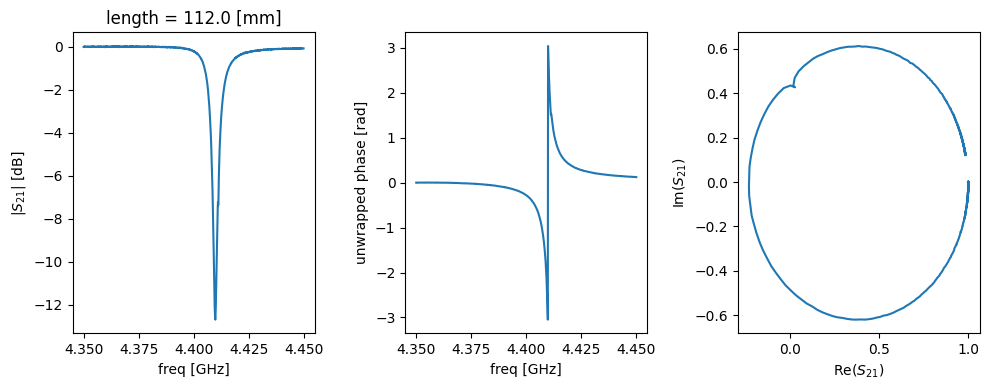

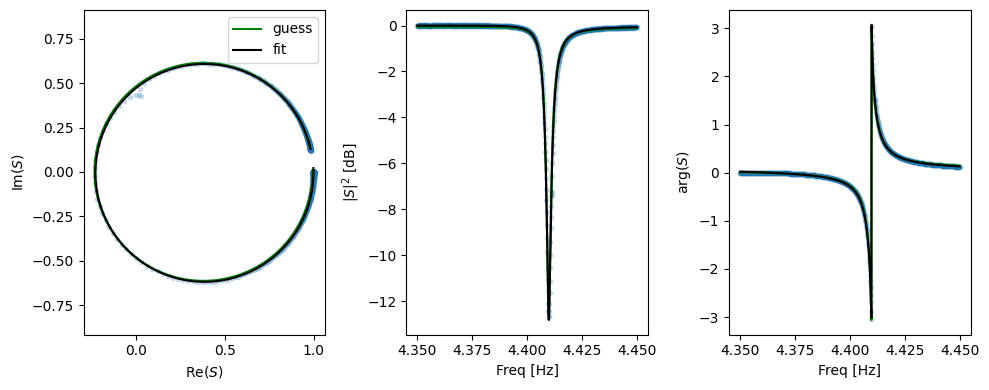

In [57]:
file_folder = '2026-06-05_10.34.45_0003_VNA_freqsweep_FFx'
full_path = base_folder+'/'+file_folder
h5_files = sorted(glob.glob(full_path+'/*.h5'))

data = xr.open_dataset(h5_files[0])

translator = {'Frequency (Hz)':['freq', 'GHz', 1e9],
              'Cavity length (mm)':['length', 'mm', 1]}

data = af.format_data_xarray(
    data=data, 
    tool='VNA',   # a VNA was used to measure this dataset
    translator=translator,
    remove_edelay=[0,100,0,0])

data = af.bgd_remover_one_cut(data, window=[0,100,0,0], order=1, is_plot=False)

fig, ax = plt.subplots(1,3,figsize=(10,4))

data.mag.plot(ax=ax[0])
ax[1].plot(data.freq.values, np.unwrap(data.isel().arg.values))
ax[1].set_ylabel('unwrapped phase [rad]')
ax[1].set_xlabel('freq [GHz]')
ax[2].plot(data.cpx.values.real, data.cpx.values.imag)
ax[2].set_ylabel('Im($S_{21}$)')
ax[2].set_xlabel('Re($S_{21}$)')
fig.tight_layout()

_data = data.isel(length=0)
model = af.ComplexCircle()

# If no `guess` is specified, the fit function automatically calls the internal guess method
result = af.fit_single(model, _data.freq.values, _data.cpx.values, guess=None)

fig, ax = plt.subplots(1,3,figsize=(10,4))
# plot data
ax[0].plot(_data.cpx.real, _data.cpx.imag, '.', alpha=0.2)
ax[1].plot(_data.freq.values, _data.mag.values, '.', alpha=0.2)
ax[2].plot(_data.freq.values, _data.arg.values, '.', alpha=0.2)

# plot guess
guess = model.guess(_data.freq.values, _data.cpx.values)
_data_guess = model.function(_data.freq.values, **guess)
ax[0].plot(_data_guess.real, _data_guess.imag, 'g-', label='guess')
ax[1].plot(_data.freq.values, 20*np.log10(np.abs(_data_guess)), 'g-')
ax[2].plot(_data.freq.values, np.angle(_data_guess), 'g-')

# plot result
_data_fit = model.function(_data.freq.values, **result.params)
ax[0].plot(_data_fit.real, _data_fit.imag, 'k-', label='fit')
ax[1].plot(_data.freq.values, 20*np.log10(np.abs(_data_fit)), 'k-')
ax[2].plot(_data.freq.values, np.angle(_data_fit), 'k-')

ax[0].axis('equal')
ax[0].legend()
ax[0].set_xlabel('Re$(S)$')
ax[0].set_ylabel('Im$(S)$')
ax[1].set_xlabel('Freq [Hz]')
ax[1].set_ylabel(r'$|S|^2$ [dB]')
ax[2].set_xlabel('Freq [Hz]')
ax[2].set_ylabel(r'arg$(S)$')
fig.tight_layout()

# quick access to fitted parameters
for name in result.params.keys():
    print(f"{name}: {result.params[name].value} +/- {result.params[name].stderr}")

result

Dropping dummy coordinate/dimension 0: "None"
New dimensions are: ['freq', 'length']
Removing edelay: -8.224863510799 * (2*pi*freq) + 307.014941961785
Removing ['freq'] background with order 1 polynomial (mode: cpx)
f0: 5.964237539365742 +/- 2.2883243701618962e-06
kt: 0.0014298233916791858 +/- 4.635615863248033e-06
re_a_in: -0.8637023965031619 +/- 0.0019190525958233757
im_a_in: 0.05672637896982862 +/- 0.0019900678368494048
T: 1.49840935835873 +/- 0.007230254437077071
re_shift: 0.9973772484306247 +/- 0.00020811696964379706
im_shift: 0.07394686943831492 +/- 0.00020964968903256273


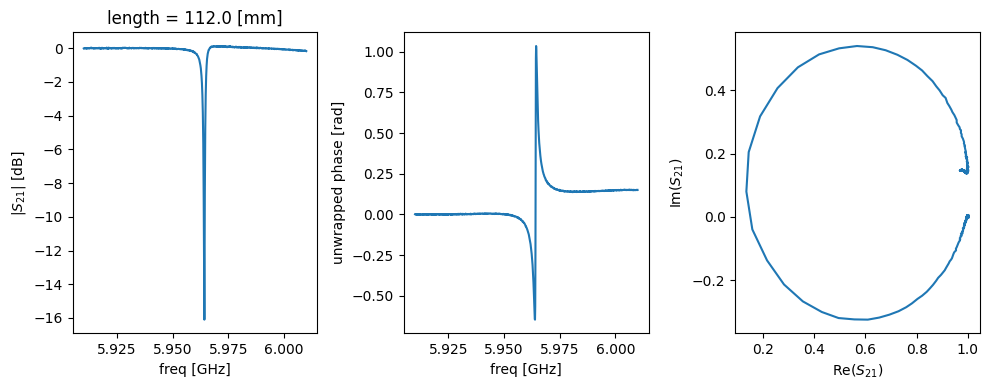

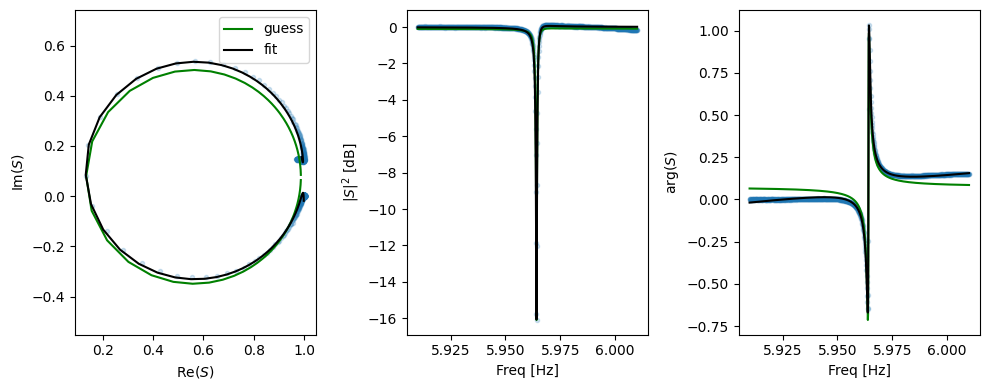

In [58]:
file_folder = '2026-06-05_10.35.06_0004_VNA_freqsweep_FFx'
full_path = base_folder+'/'+file_folder
h5_files = sorted(glob.glob(full_path+'/*.h5'))

data = xr.open_dataset(h5_files[0])

translator = {'Frequency (Hz)':['freq', 'GHz', 1e9],
              'Cavity length (mm)':['length', 'mm', 1]}

data = af.format_data_xarray(
    data=data, 
    tool='VNA',   # a VNA was used to measure this dataset
    translator=translator,
    remove_edelay=[0,100,0,0])

data = af.bgd_remover_one_cut(data, window=[0,100,0,0], order=1, is_plot=False)

fig, ax = plt.subplots(1,3,figsize=(10,4))

data.mag.plot(ax=ax[0])
ax[1].plot(data.freq.values, np.unwrap(data.isel().arg.values))
ax[1].set_ylabel('unwrapped phase [rad]')
ax[1].set_xlabel('freq [GHz]')
ax[2].plot(data.cpx.values.real, data.cpx.values.imag)
ax[2].set_ylabel('Im($S_{21}$)')
ax[2].set_xlabel('Re($S_{21}$)')
fig.tight_layout()

_data = data.isel(length=0)
model = af.ComplexCircle()

# If no `guess` is specified, the fit function automatically calls the internal guess method
result = af.fit_single(model, _data.freq.values, _data.cpx.values, guess=None)

fig, ax = plt.subplots(1,3,figsize=(10,4))
# plot data
ax[0].plot(_data.cpx.real, _data.cpx.imag, '.', alpha=0.2)
ax[1].plot(_data.freq.values, _data.mag.values, '.', alpha=0.2)
ax[2].plot(_data.freq.values, _data.arg.values, '.', alpha=0.2)

# plot guess
guess = model.guess(_data.freq.values, _data.cpx.values)
_data_guess = model.function(_data.freq.values, **guess)
ax[0].plot(_data_guess.real, _data_guess.imag, 'g-', label='guess')
ax[1].plot(_data.freq.values, 20*np.log10(np.abs(_data_guess)), 'g-')
ax[2].plot(_data.freq.values, np.angle(_data_guess), 'g-')

# plot result
_data_fit = model.function(_data.freq.values, **result.params)
ax[0].plot(_data_fit.real, _data_fit.imag, 'k-', label='fit')
ax[1].plot(_data.freq.values, 20*np.log10(np.abs(_data_fit)), 'k-')
ax[2].plot(_data.freq.values, np.angle(_data_fit), 'k-')

ax[0].axis('equal')
ax[0].legend()
ax[0].set_xlabel('Re$(S)$')
ax[0].set_ylabel('Im$(S)$')
ax[1].set_xlabel('Freq [Hz]')
ax[1].set_ylabel(r'$|S|^2$ [dB]')
ax[2].set_xlabel('Freq [Hz]')
ax[2].set_ylabel(r'arg$(S)$')
fig.tight_layout()

# quick access to fitted parameters
for name in result.params.keys():
    print(f"{name}: {result.params[name].value} +/- {result.params[name].stderr}")

result

# Large sweep 009

In [ ]:
base_folder = '/home/jovyan/steelelab/measurement_data/4KDIY/Pacome/sweep_length'

file_folder = '2026-06-05_15.19.54_0009_VNA_freqsweep_FFx'
full_path = base_folder+'/'+file_folder
h5_files = sorted(glob.glob(full_path+'/*.h5'))

data = xr.open_dataset(h5_files[0])

translator = {'Frequency (Hz)':['freq', 'GHz', 1e9],
              'Cavity length (mm)':['length', 'mm', 1]}

data = af.format_data_xarray(
    data=data, 
    tool='VNA',   # a VNA was used to measure this dataset
    translator=translator,
    remove_edelay=[0,100,0,0])

In [328]:
def fit_branches(data,
                 cpls_length,
                 f0_init,
                 bw_init,
                 bw_min = 50e-3,
                 plot=True):

    model = af.ComplexCircle()

    freq_grid = data.freq.values
    length_grid = data.length.values
    
    all_f0s, all_kts, all_results = [], [], []
    all_lengths = []

    M = np.zeros((len(length_grid), len(freq_grid)), dtype=bool)

    for j, (min_length, max_length) in enumerate(cpls_length):

        f0 = f0_init[j]
        bw = bw_init[j]

        lengths = data.sel(length=slice(min_length, max_length)).length
        
        temp_f0s, temp_kts, temp_results, temp_lengths = [], [], [], []

        for length in lengths.values:

            fmin, fmax = f0 - bw / 2, f0 + bw / 2

            data_fit = data.sel(length=length, freq=slice(fmin, fmax))

            result = af.fit_single(model,
                                   data_fit.freq.values,
                                   data_fit.cpx.values,
                                   guess=None)
            
            temp_f0s.append(result.params['f0'].value)
            temp_kts.append(result.params['kt'].value)
            temp_results.append(result)
            temp_lengths.append(length)

            f0 = temp_f0s[-1]
            bw = max(bw_min, 10 * temp_kts[-1])

            li = np.where(length_grid == length)[0][0]
            fi = np.isin(freq_grid, data_fit.freq.values)

            M[li, fi] = True
        
        all_f0s.append(temp_f0s)
        all_kts.append(temp_kts)
        all_lengths.append(temp_lengths)
        all_results.append(temp_results)

    mask_xr = xr.DataArray(M,
                           coords={"length": data.length,
                                   "freq": data.freq},
                           dims=["length", "freq"])

    data_masked = data.mag.where(mask_xr)

    if plot:
        ax = data_masked.plot(cmap="RdBu_r", add_colorbar=True).axes

        valid_freq = mask_xr.any(dim="length")
        valid_length = mask_xr.any(dim="freq")

        freq_vals = data.freq.values[valid_freq.values]
        length_vals = data.length.values[valid_length.values]

        ax.set_ylim(freq_vals.min(), freq_vals.max())
        ax.set_xlim(length_vals.min(), length_vals.max())
    
    return all_f0s, all_kts, all_lengths, all_results

In [309]:
f0s, kts, lengths, results = fit_branches(data,
                                 [(63, 77.5),
                                  (63, 78), (90, 100.5), (103, 113),
                                  (63, 71), (74, 90), (93, 113)],
                                 [4.25,
                                  5.9, 4.83, 4.55,
                                  6.277, 6.15, 6.03],
                                 [100e-3,
                                  100e-3, 100e-3, 50e-3,
                                  100e-3, 100e-3, 100e-3],
                                 plot=True)

fig = plt.figure(figsize=(12, 8))
gs = gridspec.GridSpec(1, 2)

ax_freq = fig.add_subplot(gs[0, 0])
ax_kt = fig.add_subplot(gs[0, 1])

for j in range(len(lengths)):
    ax_freq.plot(lengths[j], f0s[j])
    ax_kt.plot(lengths[j], np.array(kts[j])*1e3)

ax_freq.set_xlabel('Cavity length [mm]')
ax_freq.set_ylabel('Resonance frequency [GHz]')
ax_freq.grid(True)
ax_kt.set_xlabel('Cavity length [mm]')
ax_kt.set_ylabel('$\kappa_{tot}$ [MHz]')
ax_kt.grid(True)
fig.tight_layout()

ValueError: Shape of array too small to calculate a numerical gradient, at least (edge_order + 1) elements are required.

# Pin architecture 2

In [310]:
base_folder = '/home/jovyan/steelelab/measurement_data/4KDIY/Pacome/sweep_length'

file_folder = '2026-06-10_12.11.19_0012_VNA_freqsweep_FFx'
full_path = base_folder+'/'+file_folder
h5_files = sorted(glob.glob(full_path+'/*.h5'))

data = xr.open_dataset(h5_files[0])

translator = {'Frequency (Hz)':['freq', 'GHz', 1e9],
              'Cavity length (mm)':['length', 'mm', 1]}

data = af.format_data_xarray(
    data=data, 
    tool='VNA',   # a VNA was used to measure this dataset
    translator=translator,
    remove_edelay=[0,100,0,0])

Dropping dummy coordinate/dimension 0: "None"
New dimensions are: ['freq', 'length']
Removing edelay: -8.210432937671 * (2*pi*freq) + 203.391189218528


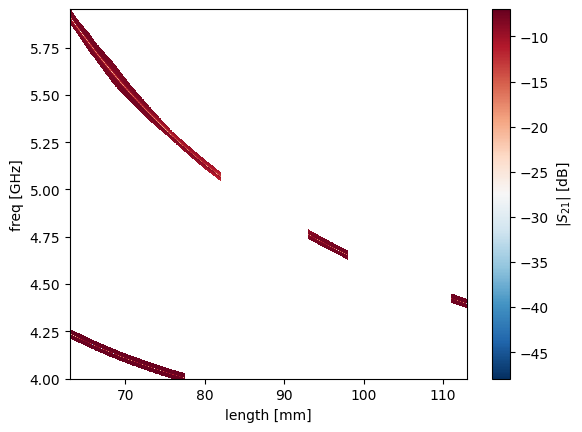

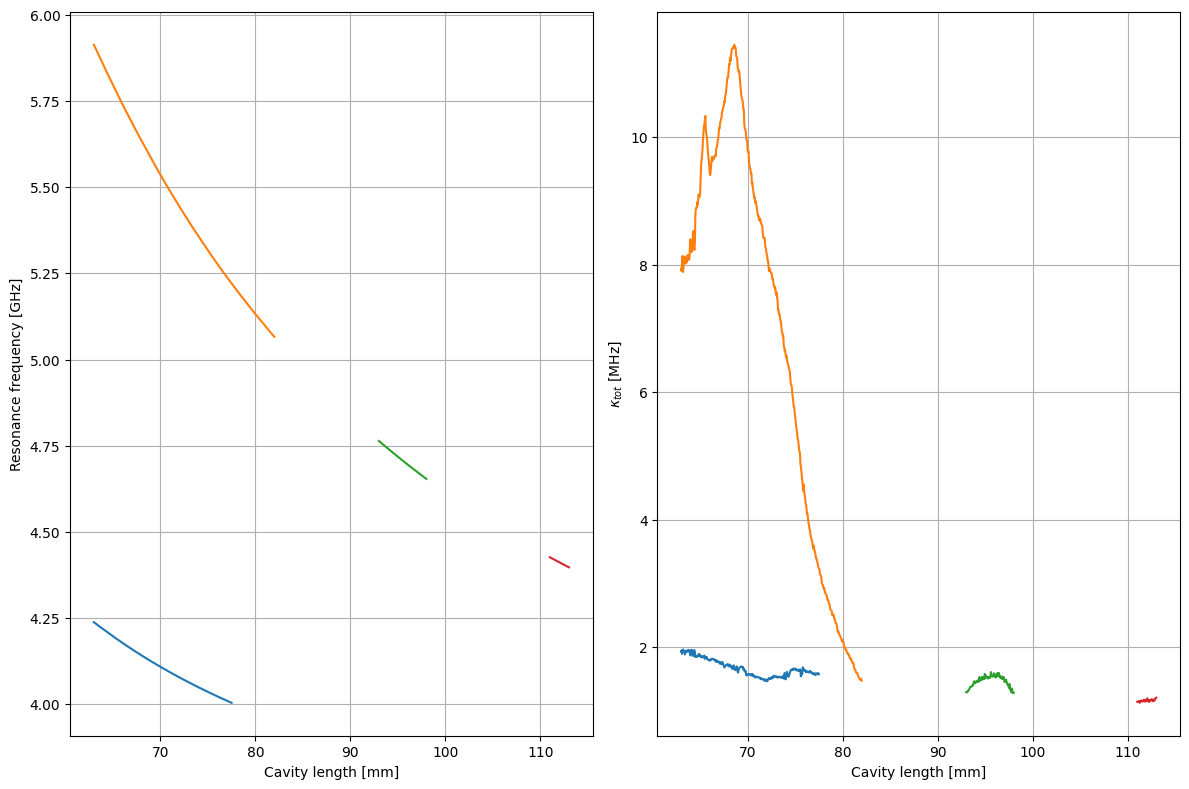

In [319]:
f0s, kts, lengths, results = fit_branches(data,
                                 [(63, 77.5), (63, 82), (93, 98), (111, 113)],
                                 [4.25, 5.91, 4.764, 4.426],
                                 [50e-3, 50e-3, 50e-3, 50e-3],
                                 plot=True)

fig = plt.figure(figsize=(12, 8))
gs = gridspec.GridSpec(1, 2)

ax_freq = fig.add_subplot(gs[0, 0])
ax_kt = fig.add_subplot(gs[0, 1])

for j in range(len(lengths)):
    ax_freq.plot(lengths[j], f0s[j])
    ax_kt.plot(lengths[j], np.array(kts[j])*1e3)

ax_freq.set_xlabel('Cavity length [mm]')
ax_freq.set_ylabel('Resonance frequency [GHz]')
ax_freq.grid(True)
ax_kt.set_xlabel('Cavity length [mm]')
ax_kt.set_ylabel('$\kappa_{tot}$ [MHz]')
ax_kt.grid(True)
fig.tight_layout()

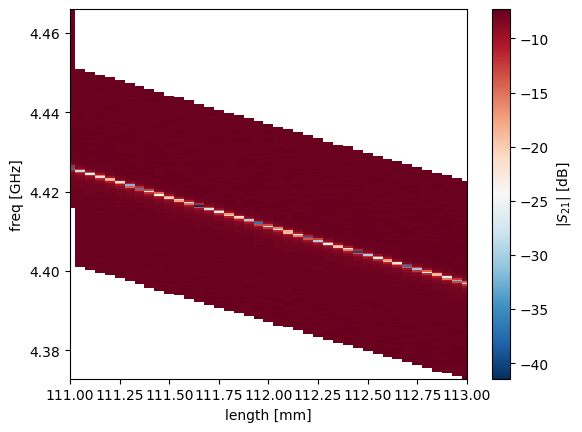

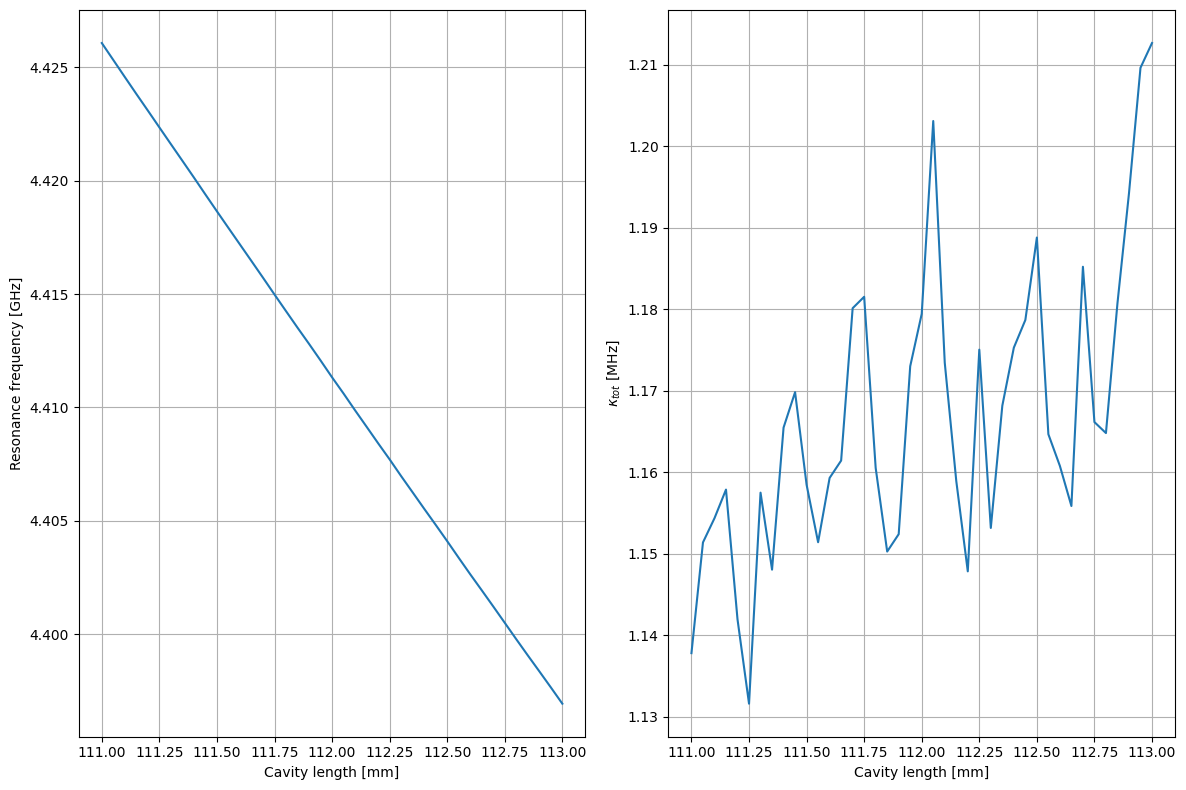

In [323]:
f0s, kts, lengths, results = fit_branches(data,
                                 [(111, 113)],
                                 [4.441],
                                 [50e-3],
                                 plot=True)

fig = plt.figure(figsize=(12, 8))
gs = gridspec.GridSpec(1, 2)

ax_freq = fig.add_subplot(gs[0, 0])
ax_kt = fig.add_subplot(gs[0, 1])

for j in range(len(lengths)):
    ax_freq.plot(lengths[j], f0s[j])
    ax_kt.plot(lengths[j], np.array(kts[j])*1e3)

ax_freq.set_xlabel('Cavity length [mm]')
ax_freq.set_ylabel('Resonance frequency [GHz]')
ax_freq.grid(True)
ax_kt.set_xlabel('Cavity length [mm]')
ax_kt.set_ylabel('$\kappa_{tot}$ [MHz]')
ax_kt.grid(True)
fig.tight_layout()

# Architecture 3

In [324]:
base_folder = '/home/jovyan/steelelab/measurement_data/4KDIY/Pacome/sweep_length'

file_folder = '2026-06-10_19.40.31_0014_VNA_freqsweep_FFx'
full_path = base_folder+'/'+file_folder
h5_files = sorted(glob.glob(full_path+'/*.h5'))

data = xr.open_dataset(h5_files[0])

translator = {'Frequency (Hz)':['freq', 'GHz', 1e9],
              'Cavity length (mm)':['length', 'mm', 1]}

data = af.format_data_xarray(
    data=data, 
    tool='VNA',   # a VNA was used to measure this dataset
    translator=translator,
    remove_edelay=[0,100,0,0])

Dropping dummy coordinate/dimension 0: "None"
New dimensions are: ['freq', 'length']
Removing edelay: -8.293317750685 * (2*pi*freq) + 205.739709338239


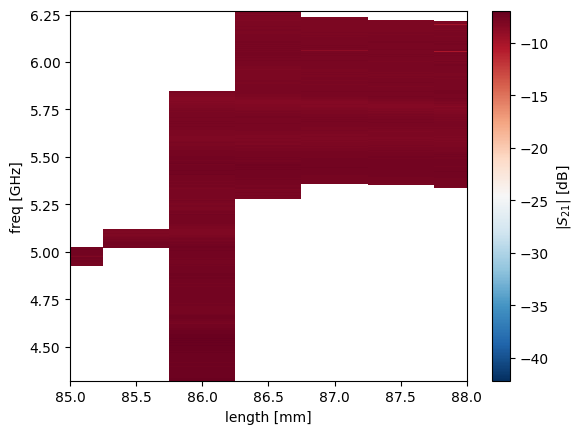

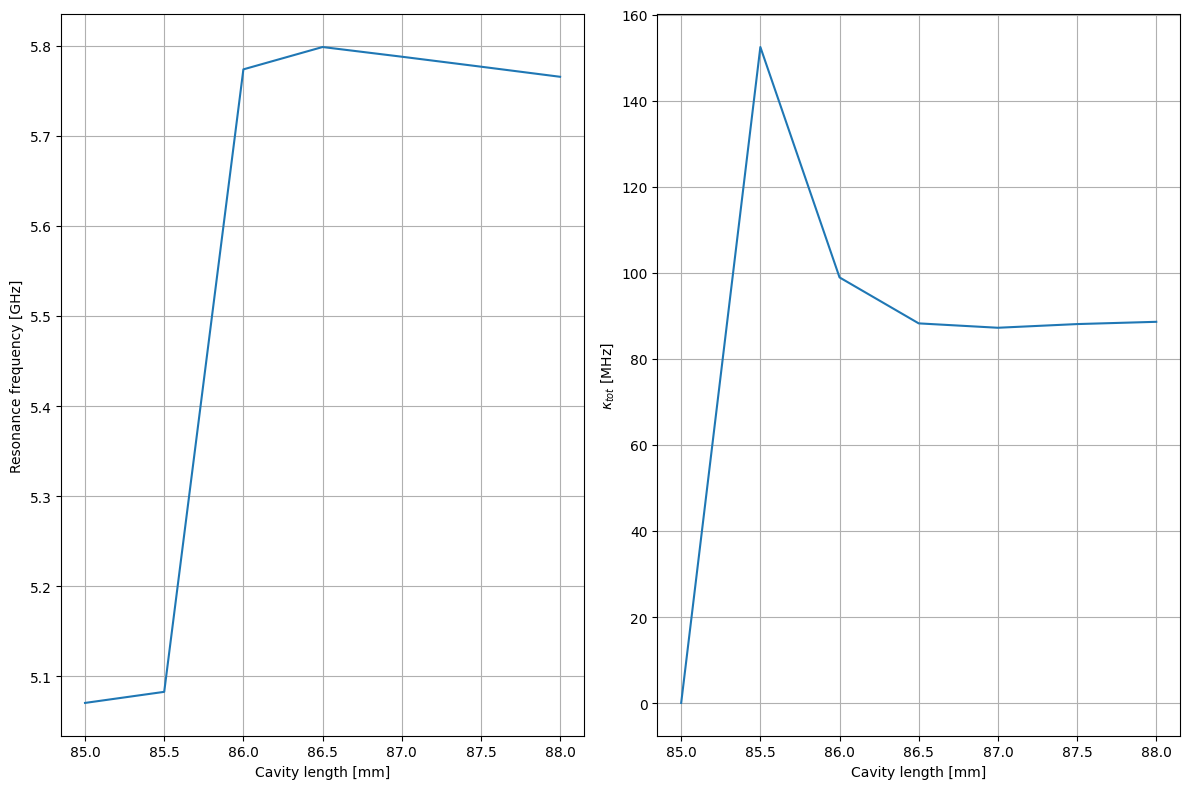

In [336]:
f0s, kts, lengths, results = fit_branches(data,
                                 [(85, 88)],
                                 [4.975],
                                 [100e-3],
                                 bw_min = 100e-3,
                                 plot=True)

fig = plt.figure(figsize=(12, 8))
gs = gridspec.GridSpec(1, 2)

ax_freq = fig.add_subplot(gs[0, 0])
ax_kt = fig.add_subplot(gs[0, 1])

for j in range(len(lengths)):
    ax_freq.plot(lengths[j], f0s[j])
    ax_kt.plot(lengths[j], np.array(kts[j])*1e3)

ax_freq.set_xlabel('Cavity length [mm]')
ax_freq.set_ylabel('Resonance frequency [GHz]')
ax_freq.grid(True)
ax_kt.set_xlabel('Cavity length [mm]')
ax_kt.set_ylabel('$\kappa_{tot}$ [MHz]')
ax_kt.grid(True)
fig.tight_layout()

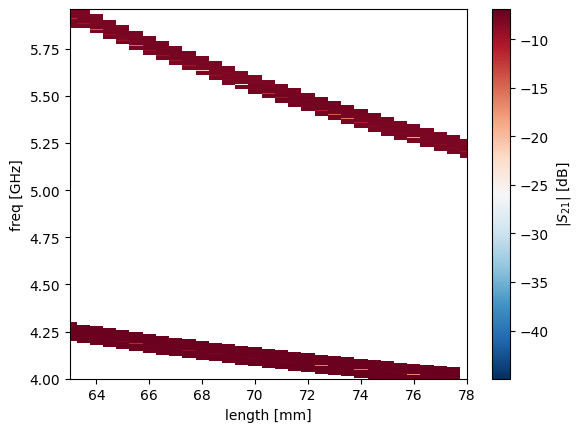

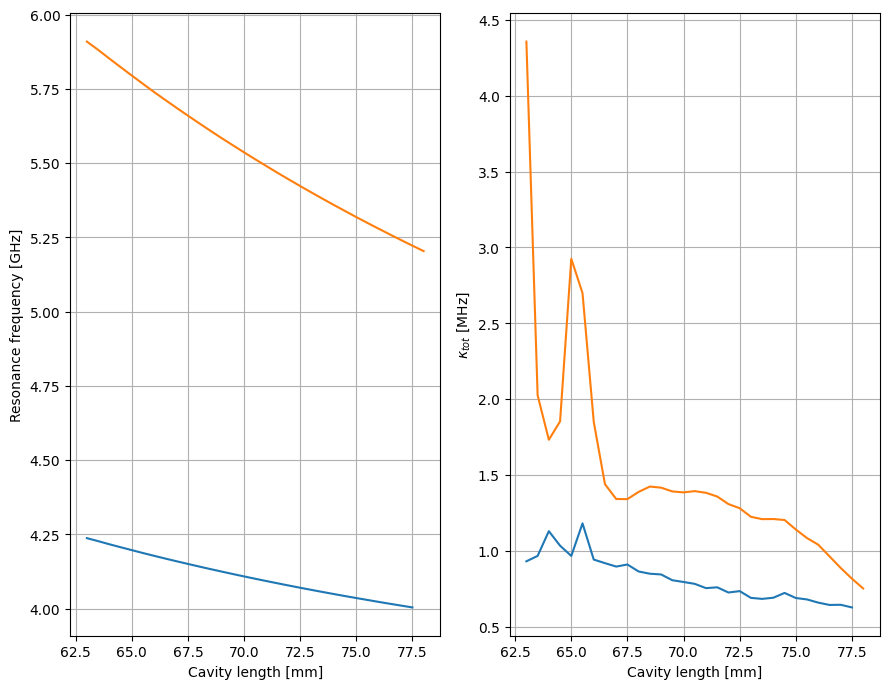

In [338]:
f0s, kts, lengths, results = fit_branches(data,
                                 [(63, 77.5), (63, 78)],
                                 [4.25, 5.91],
                                 [100e-3, 100e-3],
                                 bw_min = 100e-3,
                                 plot=True)

fig = plt.figure(figsize=(9, 7))
gs = gridspec.GridSpec(1, 2)

ax_freq = fig.add_subplot(gs[0, 0])
ax_kt = fig.add_subplot(gs[0, 1])

for j in range(len(lengths)):
    ax_freq.plot(lengths[j], f0s[j])
    ax_kt.plot(lengths[j], np.array(kts[j])*1e3)

ax_freq.set_xlabel('Cavity length [mm]')
ax_freq.set_ylabel('Resonance frequency [GHz]')
ax_freq.grid(True)
ax_kt.set_xlabel('Cavity length [mm]')
ax_kt.set_ylabel('$\kappa_{tot}$ [MHz]')
ax_kt.grid(True)
fig.tight_layout()